### **Import library**

In [2]:
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder

### **Load dataset**

In [3]:
import pandas as pd
df = pd.read_csv("Student_Performance_2026.csv")

# diabetes = datasets.load_diabetes()

In [4]:
df

,student_ID,Age,Gender,daily_screen_time_hours,social_media_hours,online_study_hours,gaming_hours,sleep_hours,attendance_percentage,offline_study_hours,previous_sem_CGPA,current_sem_CGPA
0,S011,23,Female,6.2,2.5,3.8,1.2,7.1,79,2.6,7.74,7.94
1,S012,24,Female,4.9,2.0,5.1,1.0,8.3,79,2.6,7.72,7.92
2,S013,18,Female,7.9,3.2,2.1,1.6,7.1,68,2.3,6.67,6.87
3,S014,17,Male,10.0,4.0,0.0,2.0,5.9,63,2.1,6.10,6.30
4,S015,23,Female,7.7,3.1,2.3,1.5,6.4,69,2.3,6.77,6.97
...,...,...,...,...,...,...,...,...,...,...,...,...
541,S552,17,Male,4.1,1.6,5.9,0.8,8.2,78,2.6,7.63,7.83
542,S553,24,Female,6.4,2.6,3.6,1.3,7.5,79,2.6,7.74,7.94
543,S554,17,Male,8.3,3.3,1.7,1.7,6.0,58,1.9,5.62,5.82
544,S555,21,Female,9.8,3.9,0.2,2.0,6.3,64,2.2,6.29,6.49


### **Create X and Y data matrices**

In [5]:
X = df.drop("current_sem_CGPA", axis=1)
X = X.drop("student_ID", axis=1)
X["Gender"] = LabelEncoder().fit_transform(X["Gender"])
X = X.drop("previous_sem_CGPA", axis=1)  # remove this

Y = df["current_sem_CGPA"]

## **Data split**

### **Import library**

In [6]:
from sklearn.model_selection import train_test_split

### **Perform 80/20 Data split**

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

### **Data dimension**

In [8]:
X_train.shape, Y_train.shape

((436, 9), (436,))

In [9]:
X_test.shape, Y_test.shape

((110, 9), (110,))

## **Linear Regression Model**

### **Import library**

In [10]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

### **Build linear regression**

#### Defines the regression model

In [11]:
model = linear_model.LinearRegression()
df.select_dtypes(include=['object']).head()


/tmp/ipykernel_1045645/211772757.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).head()


,student_ID,Gender
0,S011,Female
1,S012,Female
2,S013,Female
3,S014,Male
4,S015,Female


#### Build training model

In [12]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Apply trained model to make prediction (on test set)

In [13]:
Y_pred = model.predict(X_test)

## **Prediction results**

### **Print model performance**

In [14]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_test, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_test, Y_pred))

Coefficients: [-5.65249205e-05 -1.84140828e-03  1.04836341e-02 -4.98951117e-02
 -1.04836341e-02 -4.60029269e-03  1.00574424e-03  8.62845690e-02
  4.14239731e-01]
Intercept: 0.13129345072280252
Mean squared error (MSE): 0.00
Coefficient of determination (R^2): 1.00


### **String formatting**

By default r2_score returns a floating number ([more details](https://docs.scipy.org/doc/numpy-1.13.0/user/basics.types.html))

In [15]:
r2_score(Y_test, Y_pred)

0.9995155345810796

We will be using the modulo operator to format the numbers by rounding it off.

In [16]:
'%f' % 0.523810833536016

'0.523811'

We will now round it off to 3 digits

In [17]:
'%.3f' % 0.523810833536016

'0.524'

We will now round it off to 2 digits

In [18]:
'%.2f' % 0.523810833536016

'0.52'

## **Scatter plots**

### **Import library**

In [19]:
import seaborn as sns

### **Make scatter plot**

#### The Data

In [20]:
Y_test

126    7.58
448    9.15
181    8.91
237    6.43
418    5.75
       ... 
209    5.58
221    6.36
469    9.71
421    5.80
49     7.81
Name: current_sem_CGPA, Length: 110, dtype: float64

In [21]:
import numpy as np
np.array(Y_test)

array([7.58, 9.15, 8.91, 6.43, 5.75, 7.68, 6.74, 5.79, 6.59, 7.84, 6.51,
       5.83, 7.85, 6.35, 9.27, 6.31, 6.57, 5.87, 7.44, 7.09, 9.45, 6.28,
       5.81, 7.56, 8.07, 8.28, 7.14, 6.97, 6.54, 5.85, 8.78, 7.29, 7.4 ,
       6.2 , 8.29, 6.05, 6.57, 6.27, 9.03, 6.05, 5.87, 6.68, 7.45, 9.38,
       9.23, 8.01, 8.62, 7.98, 7.99, 9.08, 5.55, 7.19, 6.94, 7.92, 8.98,
       5.53, 6.28, 6.21, 6.78, 6.79, 6.33, 7.19, 7.17, 9.77, 5.99, 6.84,
       7.16, 5.69, 6.86, 5.84, 7.73, 6.  , 8.17, 9.38, 9.11, 6.27, 8.64,
       7.95, 7.88, 5.99, 5.95, 9.74, 6.84, 7.44, 6.01, 7.39, 6.13, 6.84,
       8.99, 5.61, 6.14, 9.51, 8.35, 7.53, 8.85, 6.75, 6.51, 7.71, 8.22,
       7.67, 6.19, 9.71, 7.32, 8.37, 6.21, 5.58, 6.36, 9.71, 5.8 , 7.81])

In [22]:
Y_pred

array([7.53699272, 9.16784084, 8.95599455, 6.42115817, 5.73324314,
       7.66695745, 6.72665329, 5.73647082, 6.54861028, 7.84062458,
       6.55170422, 5.82165997, 7.83992035, 6.33869086, 9.25358485,
       6.33361752, 6.55201664, 5.86501396, 7.45192721, 7.06532841,
       9.4689165 , 6.24989085, 5.82118045, 7.53729945, 8.05721494,
       8.26750871, 7.14973485, 6.93785312, 6.55223656, 5.86339919,
       8.7389669 , 7.23838385, 7.45384871, 6.24768351, 8.27155543,
       6.03477851, 6.5527036 , 6.25209241, 9.04229395, 6.03310712,
       5.86506333, 6.63555412, 7.45161833, 9.34122509, 9.25699555,
       8.0554579 , 8.65479049, 7.96513755, 7.96618533, 9.03983609,
       5.52314229, 7.15042194, 6.94057544, 7.9246968 , 8.95678005,
       5.52116716, 6.24911068, 6.25180978, 6.76521658, 6.76395014,
       6.33704115, 7.15030655, 7.15266277, 9.76868705, 5.95016471,
       6.85100698, 7.15374039, 5.65097531, 6.85300975, 5.82372852,
       7.74978734, 6.03339636, 8.13777312, 9.34265973, 9.12770

#### Making the scatter plot

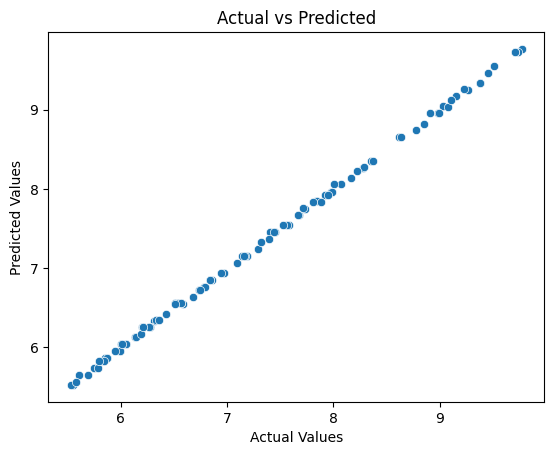

In [23]:
import matplotlib.pyplot as plt

sns.scatterplot(x=Y_test, y=Y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [24]:
import pickle

# Save the model
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as linear_regression_model.pkl")

Model saved as linear_regression_model.pkl


<Axes: xlabel='current_sem_CGPA'>

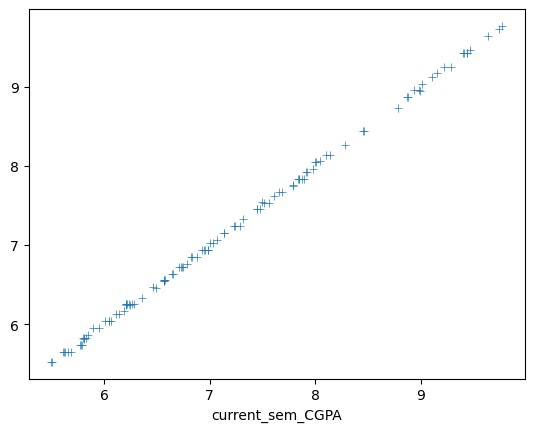

In [24]:
sns.scatterplot(x=Y_test, y=Y_pred, marker="+")

['Age', 'Gender', 'daily_screen_time_hours', 'social_media_hours', 'online_study_hours', 'gaming_hours', 'sleep_hours', 'attendance_percentage', 'offline_study_hours']


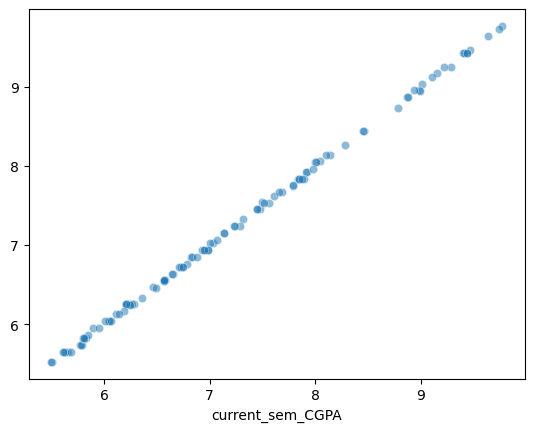

In [25]:
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.5)
print(X.columns.tolist())